### Procesamiento de Lenguaje Natural I
# **Desafío 2**

## Word embeddings con Gensim

### Objetivo

Crear embeddings propios con **Word2Vec**, analizar relaciones entre palabras y visualizar una proyección de los vectores en dos dimensiones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import reuters, stopwords
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

SEED = 42

## 1. Corpus y preprocesamiento

Se utiliza el corpus **Reuters** disponible en NLTK. Está formado por noticias en inglés y contiene vocabulario relacionado con economía, mercados, energía y commodities, por lo que resulta útil para observar relaciones entre palabras.

Para mantener el preprocesamiento simple, se pasa el texto a minúsculas, se conservan palabras alfabéticas y se eliminan stopwords.

In [2]:
nltk.download("reuters", quiet=True)
nltk.download("stopwords", quiet=True)

stop_words = set(stopwords.words("english"))
extra_stop_words = {"said", "would", "also", "one", "two", "new", "year", "reuter", "reuters"}
stop_words.update(extra_stop_words)

documents = []

for file_id in reuters.fileids():
    tokens = [word.lower() for word in reuters.words(file_id)]
    tokens = [word for word in tokens if word.isalpha() and len(word) > 2 and word not in stop_words]
    if tokens:
        documents.append(tokens)

print(f"Cantidad de documentos: {len(documents)}")
print(f"Cantidad de tokens: {sum(len(doc) for doc in documents):,}")
print("Ejemplo:", documents[0][:20])

Cantidad de documentos: 10788
Cantidad de tokens: 782,073
Ejemplo: ['asian', 'exporters', 'fear', 'damage', 'japan', 'rift', 'mounting', 'trade', 'friction', 'japan', 'raised', 'fears', 'among', 'many', 'asia', 'exporting', 'nations', 'row', 'could', 'inflict']


Se agregaron algunas palabras muy frecuentes del corpus a la lista de stopwords para que no dominen el análisis. No se realiza un preprocesamiento más complejo porque para cumplir con el objetivo alcanza con una limpieza básica.

Luego del preprocesamiento se conservan **10.788 documentos** y aproximadamente **782 mil tokens**. El corpus mantiene un volumen suficiente para entrenar los embeddings y, al mismo tiempo, se reducen términos muy frecuentes que aportan poca información.


## 2. Entrenamiento de Word2Vec

Se entrena un modelo **Skip-gram** (`sg=1`). En esta arquitectura, una palabra objetivo se utiliza para aprender las palabras que aparecen en su contexto.

Se usa una dimensionalidad de 100, una ventana de contexto de 5 palabras y `min_count=10` para descartar términos con muy pocas apariciones. Se mantiene una configuración simple, suficiente para analizar las relaciones aprendidas en el corpus.


In [3]:
%%capture --no-stdout --no-display
# Evita mostrar mensajes internos no fatales de Gensim durante el entrenamiento.

w2v_model = Word2Vec(
    sentences=documents,
    vector_size=100,
    window=5,
    min_count=10,
    workers=1,
    sg=1,
    epochs=10,
    seed=SEED
)

print(f"Tamaño del vocabulario: {len(w2v_model.wv.index_to_key)}")

Tamaño del vocabulario: 6651


El vocabulario final contiene **6.651 términos**. El uso de `min_count=10` permite trabajar con palabras que aparecen suficientes veces como para contar con contexto durante el entrenamiento, evitando que términos muy poco frecuentes agreguen ruido.


## 3. Palabras más y menos similares

Se seleccionan cuatro términos representativos del corpus: `oil`, `market`, `bank` y `wheat`. La similitud se calcula mediante similitud coseno entre embeddings.

In [4]:
terms = ["oil", "market", "bank", "wheat"]

for word in terms:
    print(f"\n{word.upper()}")
    for similar_word, score in w2v_model.wv.most_similar(word, topn=5):
        print(f"  {similar_word:15s} {score:.3f}")


OIL
  crude           0.701
  liquefied       0.626
  lpg             0.610
  liquids         0.598
  aramco          0.593

MARKET
  markets         0.642
  gilts           0.542
  dip             0.517
  surged          0.511
  seemed          0.509

BANK
  banks           0.661
  central         0.627
  satoshi         0.622
  sanwa           0.581
  lending         0.572

WHEAT
  barley          0.689
  usda            0.678
  durum           0.670
  corn            0.664
  thous           0.651


Los términos más similares no tienen por qué ser sinónimos. Word2Vec aprende palabras que aparecen en **contextos parecidos**, por lo que también puede capturar asociaciones temáticas.

Los resultados son coherentes con el dominio de Reuters. Por ejemplo, `oil` aparece relacionado con `crude`, `lpg` y `aramco`; `bank` con `banks`, `central` y `lending`; y `wheat` con `barley`, `durum` y `corn`. Esto indica que el modelo logró aprender relaciones propias de noticias económicas y de commodities.


In [5]:
def least_similar(model, word, topn=5):
    similarities = model.wv.cosine_similarities(model.wv[word], model.wv.vectors)
    indices = np.argsort(similarities)[:topn]
    return [(model.wv.index_to_key[i], similarities[i]) for i in indices]

for word in terms:
    print(f"\n{word.upper()}")
    for different_word, score in least_similar(w2v_model, word):
        print(f"  {different_word:15s} {score:.3f}")


OIL
  grace           -0.118
  agrees          -0.062
  managers        -0.054
  joining         -0.042
  legal           -0.036

MARKET
  lease           -0.060
  power           -0.054
  crowley         -0.052
  old             -0.049
  lloyd           -0.038

BANK
  removal         -0.107
  true            -0.106
  human           -0.092
  structure       -0.074
  ethanol         -0.063

WHEAT
  name            -0.075
  tie             -0.071
  holds           -0.071
  working         -0.068
  sumitomo        -0.055


En los términos menos similares aparecen palabras cuyos contextos de uso son muy distintos de los términos de referencia. Por ejemplo, para `oil` aparecen palabras como `grace`, `managers` o `legal`, mientras que para `wheat` aparecen `name`, `tie` y `holds`.

Esto **no significa que sean antónimos**. Solo indica que sus vectores tienen una similitud coseno baja dentro del espacio aprendido por el modelo.


## 4. Reducción de dimensionalidad

Para visualizar los embeddings se toman los términos elegidos y sus vecinos más cercanos. Luego se proyectan de 100 a 2 dimensiones con **t-SNE**.

t-SNE es una técnica no lineal que intenta conservar relaciones locales entre los vectores, por lo que resulta útil como herramienta de visualización y exploración. La proyección no debe interpretarse como una reproducción exacta del espacio original.

Se limita la cantidad de términos con `MAX_WORDS = 40` para obtener una visualización legible.


In [6]:
MAX_WORDS = 40

words_to_plot = []
for word in terms:
    words_to_plot.append(word)
    words_to_plot.extend([w for w, _ in w2v_model.wv.most_similar(word, topn=10)])

# Eliminar repetidos manteniendo el orden
words_to_plot = list(dict.fromkeys(words_to_plot))[:MAX_WORDS]

vectors = w2v_model.wv[words_to_plot]

perplexity = min(10, len(words_to_plot) - 1)
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto"
)

vectors_2d = tsne.fit_transform(vectors)
print(f"Palabras graficadas: {len(words_to_plot)}")

Palabras graficadas: 40


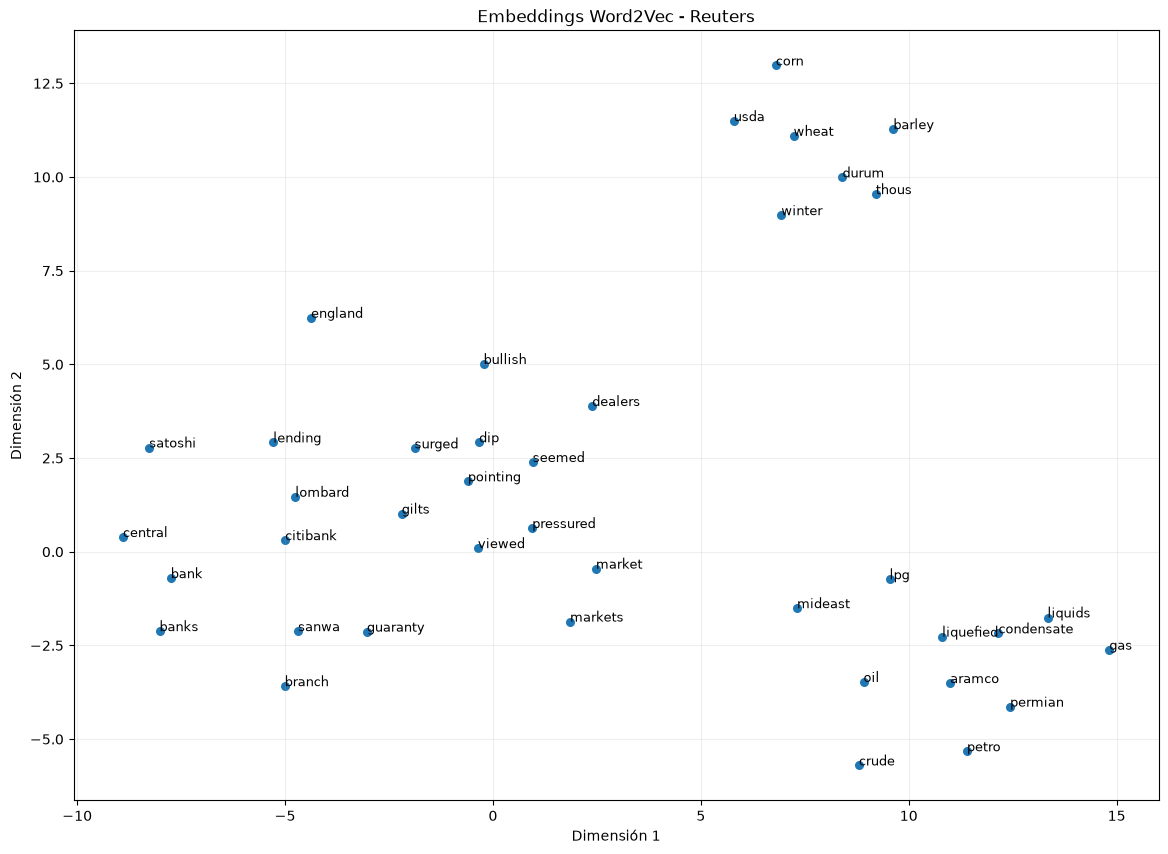

In [7]:
plt.figure(figsize=(14, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=30)

for i, word in enumerate(words_to_plot):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=9)

plt.title("Embeddings Word2Vec - Reuters")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(alpha=0.2)
plt.show()

### Interpretación de la visualización

En la proyección se observan varios grupos coherentes con el dominio del corpus. Alrededor de `wheat` aparecen términos agrícolas como `barley`, `corn`, `durum` y `usda`. También se distingue un grupo relacionado con petróleo y energía, con palabras como `oil`, `crude`, `lpg`, `liquefied` y `aramco`.

En el caso de `bank` aparecen términos financieros como `banks`, `central`, `sanwa` y `lending`, mientras que `market` se relaciona con palabras como `markets`, `gilts` y `surged`.

Los grupos no están perfectamente separados, lo cual es esperable. Los embeddings fueron aprendidos a partir de los contextos del corpus y t-SNE reduce vectores de 100 dimensiones a solo dos. Por este motivo, el gráfico se interpreta de forma **exploratoria**, priorizando los grupos y relaciones locales.


## Conclusión

El modelo logró aprender relaciones entre palabras a partir del contexto del corpus sin utilizar embeddings preentrenados. Los resultados muestran que Word2Vec genera representaciones densas donde palabras utilizadas en contextos similares quedan próximas en el espacio vectorial.

En Reuters se recuperan asociaciones claras entre términos de energía, finanzas y agricultura. La proyección con t-SNE permite observar estas relaciones de manera visual, aunque debe entenderse como una representación exploratoria de un espacio originalmente de mayor dimensionalidad.
